# Build a Retrieval Augmented Generation (RAG) App: Part 1

**remarks** - This RAG Agent works in a simplified manner with the `State`. It does not append nor requires a history. So for a more complex agent and `State` handling it is better to look at the different tutorial.

One of the most powerful applications enabled by LLMs is sophisticated question-answering (Q&A) chatbots. These are applications that can answer questions about specific source information. These applications use a technique known as Retrieval Augmented Generation, or RAG.

This is a multi-part tutorial:

- Part 1 (this guide) introduces RAG and walks through a minimal implementation.
- Part 2 extends the implementation to accommodate conversation-style interactions and multi-step retrieval processes.

This tutorial will show how to build a simple Q&A application over a text data source. Along the way we’ll go over a typical Q&A architecture and highlight additional resources for more advanced Q&A techniques. We’ll also see how LangSmith can help us trace and understand our application. LangSmith will become increasingly helpful as our application grows in complexity.

If you're already familiar with basic retrieval, you might also be interested in this high-level overview of different retrieval techniques.

**Note**: Here we focus on Q&A for unstructured data. If you are interested for RAG over structured data, check out our tutorial on doing question/answering over SQL data.

In [1]:
import sys
import os
import openai

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key, tavily_api_key

#openaai.api_key = api_key
os.environ['OPENAI_API_KEY'] = api_key
os.environ['TAVILY_API_KEY'] = tavily_api_key

## Overview

A typical RAG application has two main components:

**Indexing**: a pipeline for ingesting data from a source and indexing it. This usually happens offline.

**Retrieval and generation**: the actual RAG chain, which takes the user query at run time and retrieves the relevant data from the index, then passes that to the model.

Note: the indexing portion of this tutorial will largely follow the semantic search tutorial.

The most common full sequence from raw data to answer looks like:

## Indexing

1. **Load**: First we need to load our data. This is done with Document Loaders.
2. **Split**: Text splitters break large `Documents` into smaller chunks. This is useful both for indexing data and passing it into a model, as large chunks are harder to search over and won't fit in a model's finite context window.
3. **Store**: We need somewhere to store and index our splits, so that they can be searched over later. This is often done using a VectorStore and Embeddings model.

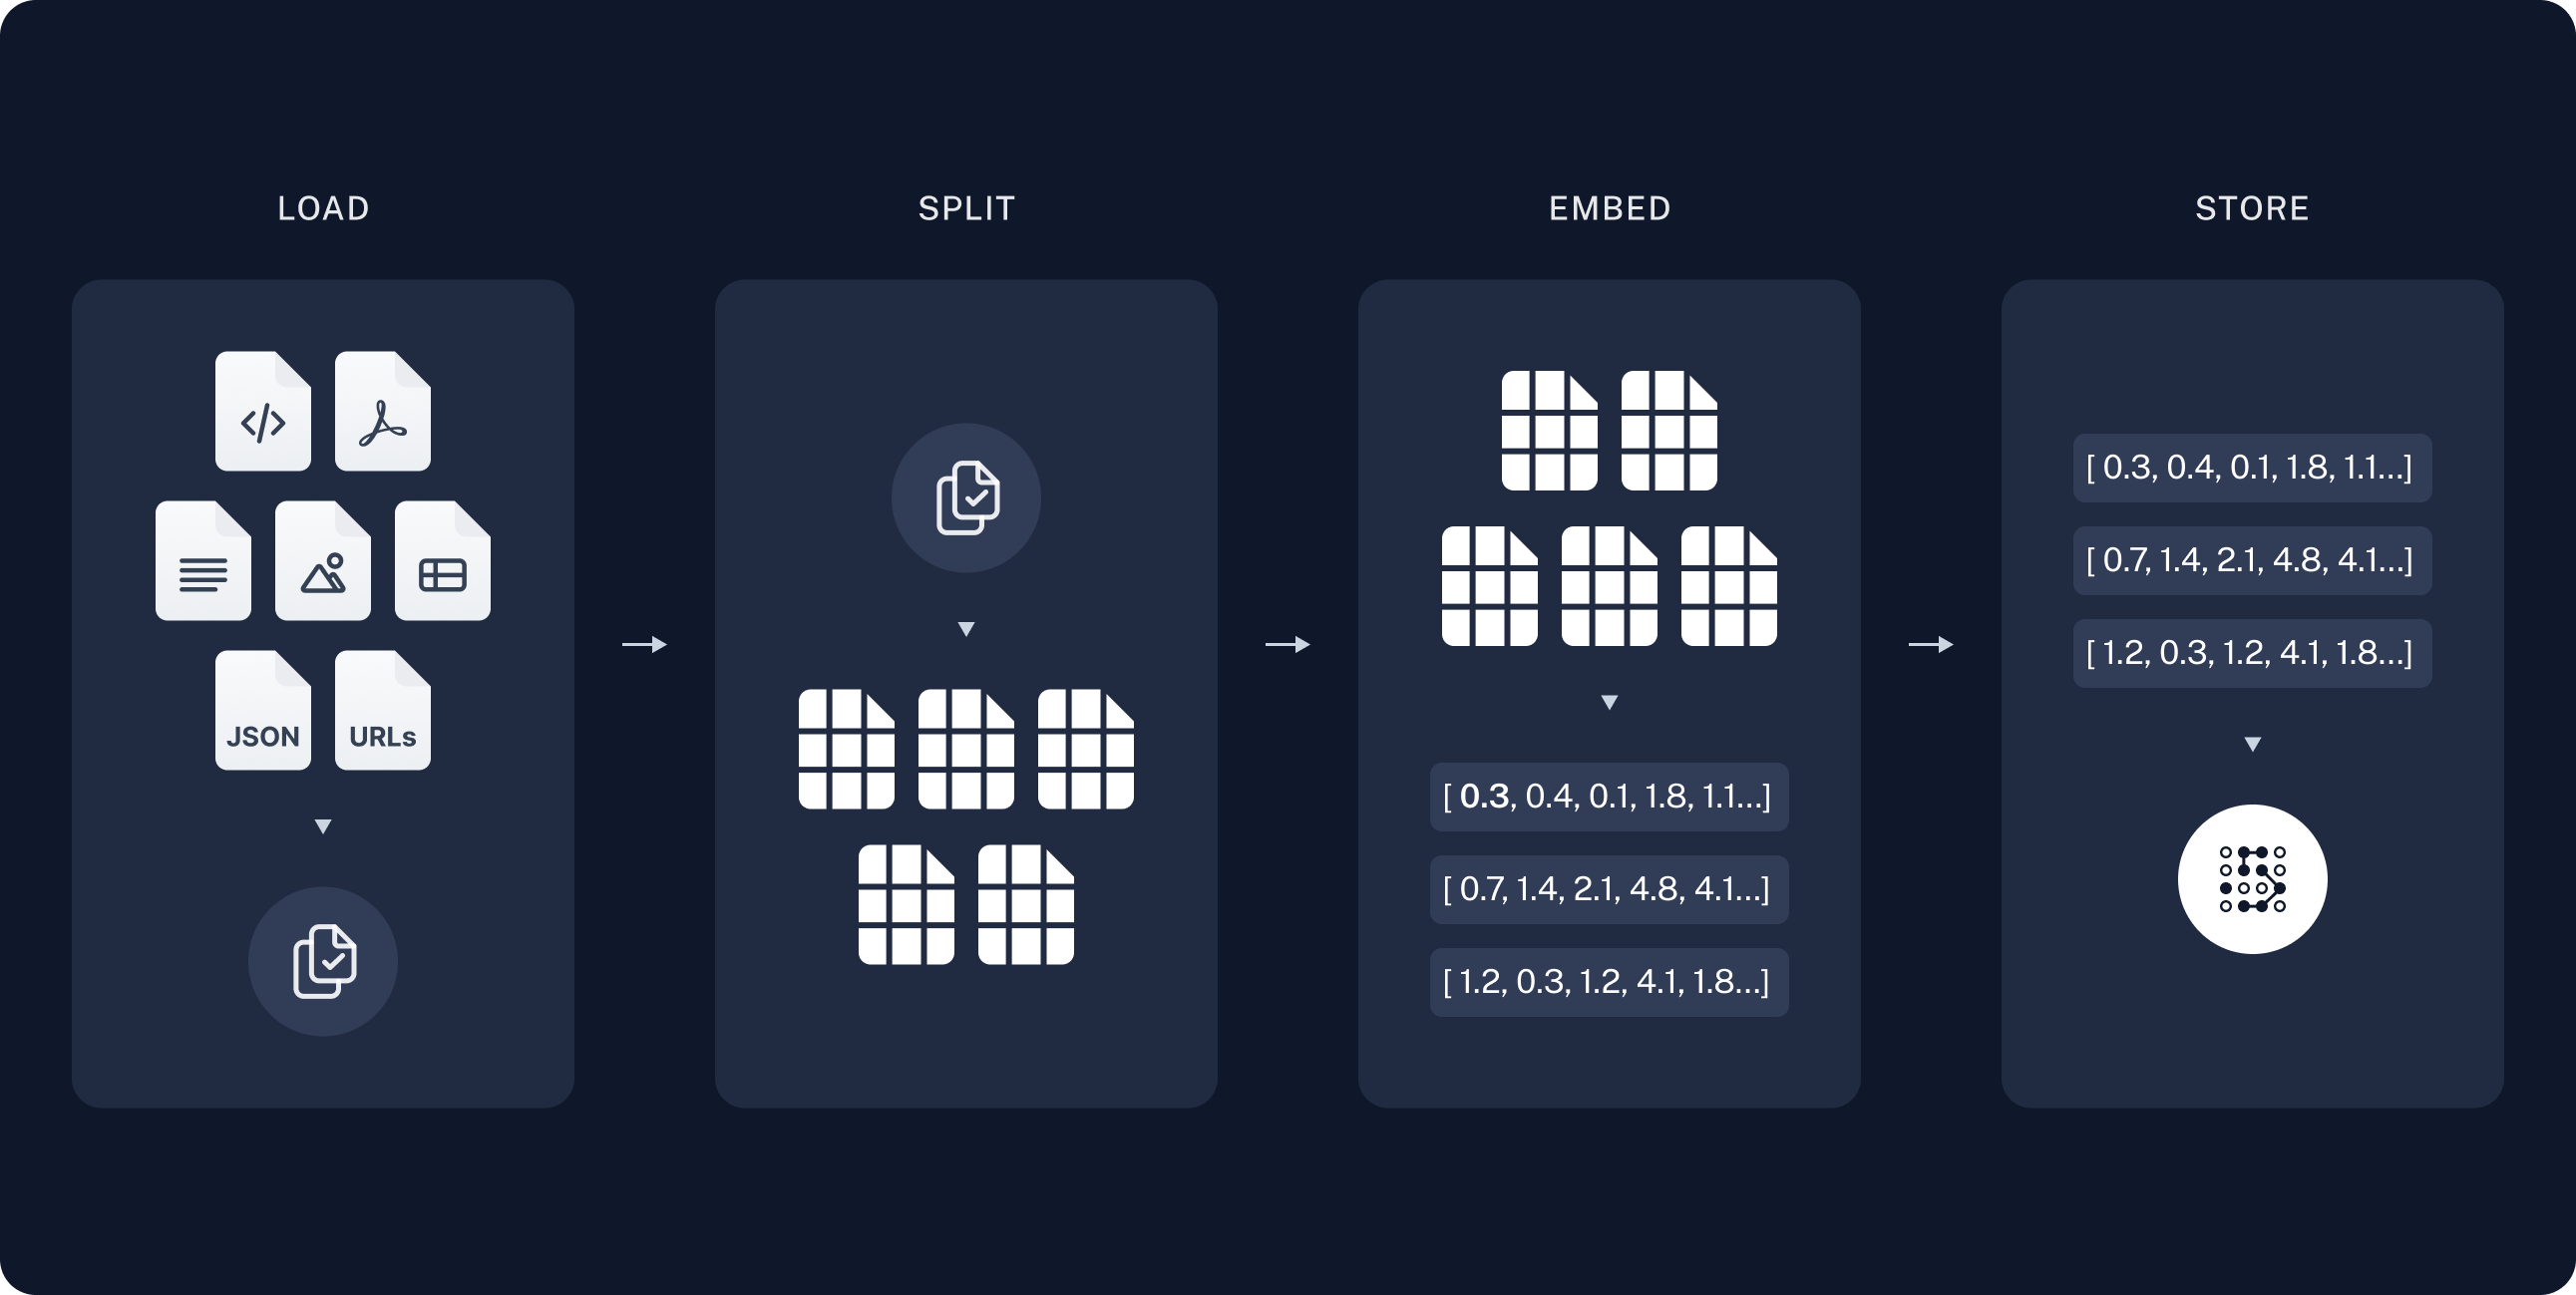

## Retrieval and generation
4. **Retrieve**: Given a user input, relevant splits are retrieved from storage using a Retriever.
5. **Generate**: A ChatModel / LLM produces an answer using a prompt that includes both the question with the retrieved data

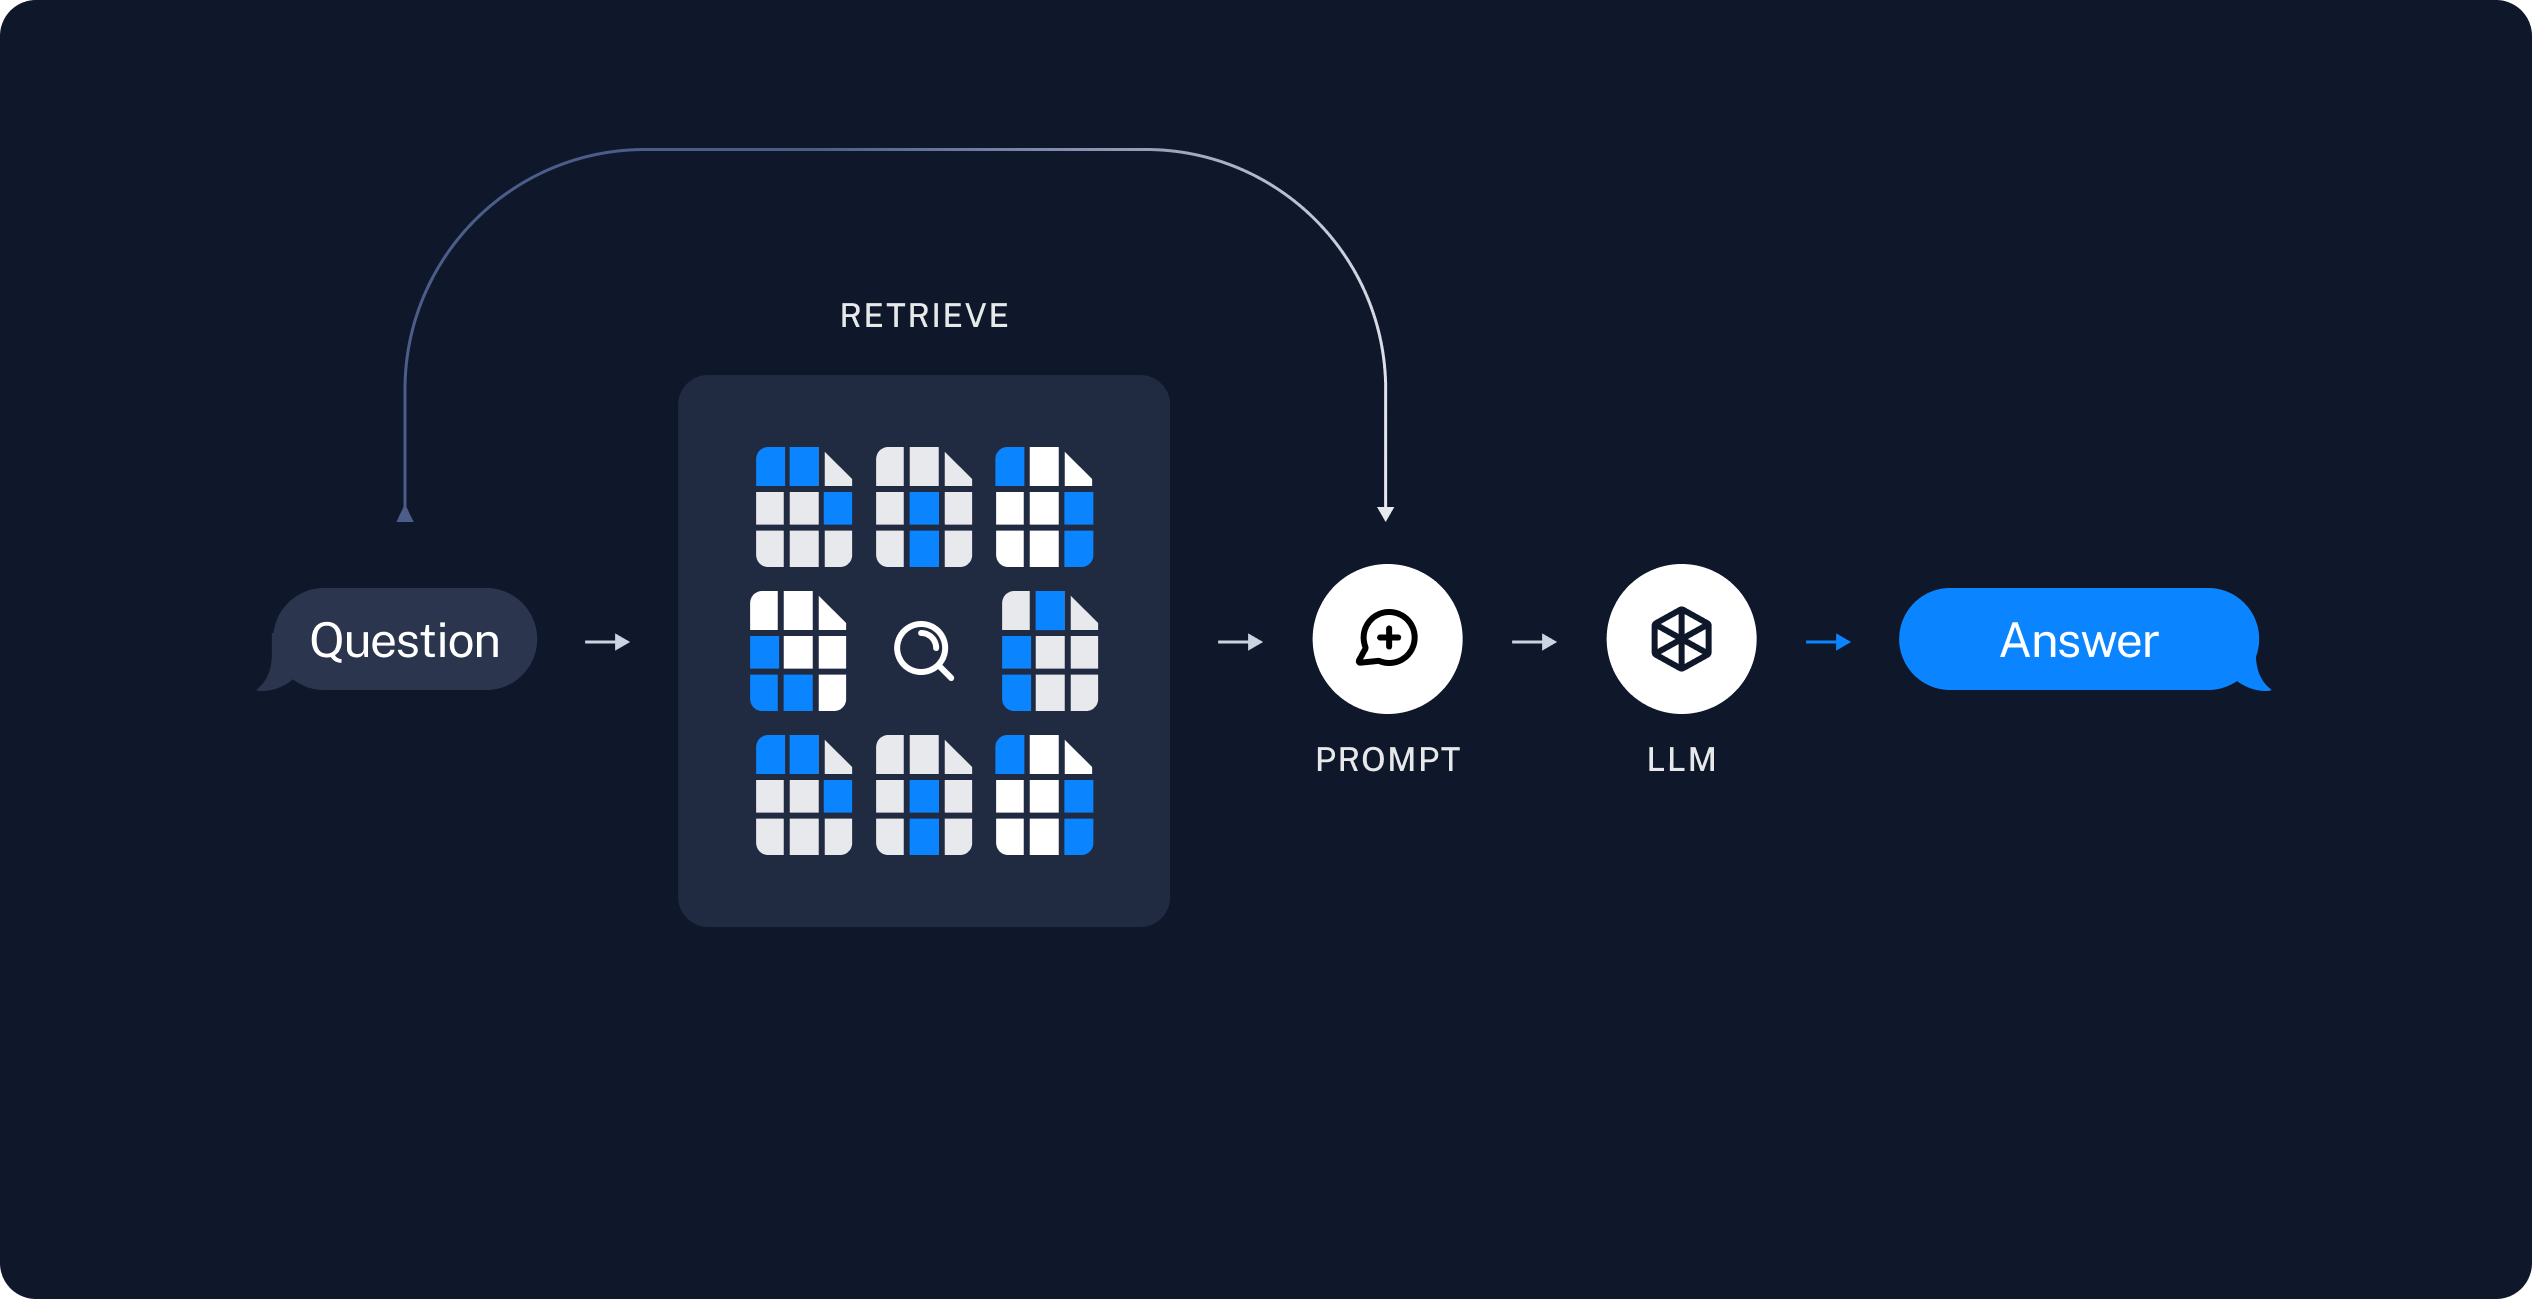

Once we've indexed our data, we will use LangGraph as our orchestration framework to implement the retrieval and generation steps.

In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")

In [3]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [4]:
from langchain_core.vectorstores import InMemoryVectorStore

# create a vector store with the embeddings
vector_store = InMemoryVectorStore(embeddings)

## Preview

In this guide we’ll build an app that answers questions about the website's content. The specific website we will use is the LLM Powered Autonomous Agents blog post by Lilian Weng, which allows us to ask questions about the contents of the post.

We can create a simple indexing pipeline and RAG chain to do this in ~50 lines of code.

In [5]:
import bs4
from typing import List, TypedDict
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph, END

USER_AGENT environment variable not set, consider setting it to identify your requests.


## Loading documents

We need to first load the blog post contents. We can use DocumentLoaders for this, which are objects that load in data from a source and return a list of Document objects.

In this case we’ll use the WebBaseLoader, which uses `urllib` to load HTML from web URLs and `BeautifulSoup` to parse it to text. We can customize the HTML -> text parsing by passing in parameters into the `BeautifulSoup` parser via `bs_kwargs` (see BeautifulSoup docs). In this case only HTML tags with class “post-content”, “post-title”, or “post-header” are relevant, so we’ll remove all others.

In [6]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

# Only keep post title, headers, and content from the full HTML.
bs4_strainer = bs4.SoupStrainer(class_=("post-title", "post-header", "post-content"))
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs={"parse_only": bs4_strainer},
)
docs = loader.load()

assert len(docs) == 1
print(f"Total characters: {len(docs[0].page_content)}")

Total characters: 43047


In [7]:
print(docs[0].page_content[:500])



      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In


## Splitting documents

Our loaded document is over 42k characters which is too long to fit into the context window of many models. Even for those models that could fit the full post in their context window, models can struggle to find information in very long inputs.

To handle this we’ll split the `Document` into chunks for embedding and vector storage. This should help us retrieve only the most relevant parts of the blog post at run time.

As in the semantic search tutorial, we use a RecursiveCharacterTextSplitter, which will recursively split the document using common separators like new lines until each chunk is the appropriate size. This is the recommended text splitter for generic text use cases.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 63 sub-documents.


## Storing documents

Now we need to index our 66 text chunks so that we can search over them at runtime. Following the semantic search tutorial, our approach is to embed the contents of each document split and insert these embeddings into a vector store. Given an input query, we can then use vector search to retrieve relevant documents.

We can embed and store all of our document splits in a single command using the vector store and embeddings model selected at the start of the tutorial.

In [9]:
document_ids = vector_store.add_documents(documents=all_splits)

print(document_ids[:3])

['9ef5f339-a159-4aab-ad31-fd3807553108', '74c41038-4673-45ad-9d47-652d048a765a', 'a85c315f-ddd9-4ee3-b43e-02848a7c0039']


> **Note** - I have not seen the below before where a prompt template is pulled in from `hub`. Maybe good to check it out 

## Retrieval and Generation

Now let’s write the actual application logic. We want to create a simple application that takes a user question, searches for documents relevant to that question, passes the retrieved documents and initial question to a model, and returns an answer.

For generation, we will use the chat model selected at the start of the tutorial.

We’ll use a prompt for RAG that is checked into the LangChain prompt hub (here).

`https://smith.langchain.com/hub/` - for example prompt

In [10]:
from langchain import hub

# N.B. for non-US LangSmith endpoints, you may need to specify
# api_url="https://api.smith.langchain.com" in hub.pull.
prompt = hub.pull("rlm/rag-prompt")

example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

/home/sacha/.cache/pypoetry/virtualenvs/datacamp-ml-M1zkPQRL-py3.10/lib/python3.10/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


In [11]:
# The interesting part of the prompt
prompt.messages[0].prompt.template

"You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"

We'll use LangGraph to tie together the retrieval and generation steps into a single application. This will bring a number of benefits:

- We can define our application logic once and automatically support multiple invocation modes, including streaming, async, and batched calls.
- We get streamlined deployments via LangGraph Platform.
- LangSmith will automatically trace the steps of our application together.
- We can easily add key features to our application, including persistence and human-in-the-loop approval, with minimal code changes.

To use LangGraph, we need to define three things:

1. The state of our application;
2. The nodes of our application (i.e., application steps);
3. The "control flow" of our application (e.g., the ordering of the steps).

**State**:
The state of our application controls what data is input to the application, transferred between steps, and output by the application. It is typically a `TypedDict`, but can also be a Pydantic BaseModel.

For a simple RAG application, we can just keep track of the input question, retrieved context, and generated answer:

In [12]:
# Define a state for the application
# We need somekind of state to store messages when we call the agent later on
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

**Nodes (application steps)**

Let's start with a simple sequence of two steps: retrieval and generation.

In [13]:
# Define application steps
def retrieve(state: State):
    """
    Function will be connected to a node.

    The function looks up context documents based on the `questions` key
    """
    retrieved_docs = vector_store.similarity_search(state["question"], k=4)
    return {"context": retrieved_docs}

In [14]:
state_example = {"question": "What is Task Decomposition?"}

# This should return the best 4 matching docs (we have set k=4 above)
context_docs = retrieve(state_example)['context']
state_example['context'] = context_docs

# not used now but below it is used
merged_docs = "\n".join([doc.page_content for doc in context_docs])

# result is a state with now two keys
state_example.keys()

dict_keys(['question', 'context'])

> **Remark** - why is the `.similarity_search` used instead of creating a retriever with `vector_stors.as_retriever`

#### Using `retriever = vector_store.as_retriever()`

- This wraps your vector store in a **Retriever interface**.  
- Now you can call `retriever.get_relevant_documents(query)` (or just pass the retriever into tools, agents, and chains).  

**Example:**
```python
retriever = vector_store.as_retriever(search_kwargs={"k": 4})
retrieved_docs = retriever.get_relevant_documents("types of reward hacking")
```

**Pros**:

- Standard interface — works the same whether the backend is FAISS, Pinecone, Chroma, etc.
- Plays nicely with LangChain agents and tools (create_retriever_tool expects a retriever, not a raw vector store).
- You can configure it once (k, filters, etc.) instead of repeating params in every call.

**Cons**:
- Slightly more abstraction — you don’t see exactly what vector store method is being called.
- If you only ever use one-off similarity searches, it’s an extra step.

In [20]:
def generate(state: State):
    """
    Function will be connected to a node.

    The function looks up context documents based on the `questions` key
    """
    # merge all context documents in one big string
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    # print(docs_content)

    # prompt below should be called prompt_template
    # messages should be called prompt. It holds the list of messages
    # that serve as input to the llm
    messages = prompt.invoke({"question": state["question"], "context": docs_content})

    # call the llm with the messages
    response = llm.invoke(messages)
    return {"answer": response.content}


In [21]:
generate(state_example)

{'answer': 'Task decomposition is the process of breaking down a complex task into smaller, manageable steps or subgoals. This can be achieved through various methods, including simple prompting techniques, task-specific instructions, or human inputs. It helps in planning and executing tasks more effectively by allowing an agent to approach them step by step.'}

#### remark on `state`

In **LangGraph**, each node function takes the current `state` and returns a **partial state update** as a dictionary.  

- You don’t manually mutate the state.  
- Instead, you return a dict with only the keys you want to update.  
- LangGraph automatically merges these updates into the running state under the hood.  

That’s why this works:

```python
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}   # merged into state["context"]

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    ...
```

So when generate runs, the state already has context populated — even though you never explicitly wrote state["context"] = ....

👉 This is LangGraph’s built-in state management. Your node functions only describe what changes, LangGraph ensures the state is updated and passed along.

Our retrieval step simply runs a similarity search using the input question, and the generation step formats the retrieved context and original question into a prompt for the chat model.

**Control flow**
Finally, we compile our application into a single graph object. In this case, we are just connecting the retrieval and generation steps into a single sequence.

In [22]:
# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

`StateGraph(State).add_sequence([retrieve, generate])`

This is a shortcut for building a linear pipeline of nodes.  
It automatically:

1. Creates a graph with the given `State` definition.  
2. Adds each function in the list (`retrieve`, `generate`) as a node.  
3. Wires them together in order, e.g.:



In [23]:
response = graph.invoke({"question": "What is Task Decomposition?"})
print(response["answer"])

Task decomposition is the process of breaking down a complex task into smaller, manageable sub-tasks. It can be achieved through various methods, including prompting large language models (LLMs) to outline steps, using task-specific instructions, or incorporating human inputs. Techniques like Chain of Thought (CoT) and Tree of Thoughts enhance this process by structuring reasoning and exploring multiple possibilities.


In [24]:
result = graph.invoke({"question": "What is Task Decomposition?"})

print(f"Context: {result['context']}\n\n")
print(f"Answer: {result['answer']}")

Context: [Document(id='8af38318-23b8-41f2-96dc-5c419665726b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 2578}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outsourced to an external tool,

In [26]:
graph_builder = StateGraph(State)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

# Start → retrieve → END
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

In [27]:
# I do not get my graph visualized this way
# graph

In [29]:
result = graph.invoke({"question": "What is Task Decomposition?"})

# print(f"Context: {result['context']}\n\n")
print(f"Answer: {result['answer']}")

Answer: Task decomposition is the process of breaking down a complex task into smaller, more manageable subtasks. This can be achieved through various methods, including simple prompting to generate steps, using task-specific instructions, or incorporating human inputs. Advanced techniques like Chain of Thought (CoT) and Tree of Thoughts further enhance task decomposition by exploring reasoning possibilities and structuring the problem-solving process.


Stream steps:

In [31]:
for step in graph.stream(
    {"question": "What is Task Decomposition?"}, stream_mode="updates"
):
    print(f"{step}\n\n----------------\n")

{'retrieve': {'context': [Document(id='8af38318-23b8-41f2-96dc-5c419665726b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 2578}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outsourced to a

Stream tokens:

In [32]:
for message, metadata in graph.stream(
    {"question": "What is Task Decomposition?"}, stream_mode="messages"
):
    print(message.content, end="|")

|Task| decomposition| is| the| process| of| breaking| down| a| complex| task| into| smaller|,| more| manageable| sub|-t|asks| or| steps|.| This| can| be| achieved| using| techniques| such| as| simple| prompting|,| task|-specific| instructions|,| or| human| inputs|.| Additionally|,| advanced| methods| like| Chain| of| Thought| (|Co|T|)| and| Tree| of| Thoughts| allow| for| structured| reasoning| and| exploration| of| multiple| possibilities| in| the| task|-solving| process|.||

#### Final snippet 

In [46]:
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict

# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

# Index chunks
_ = vector_store.add_documents(documents=all_splits)

# Define prompt for question-answering
# N.B. for non-US LangSmith endpoints, you may need to specify
# api_url="https://api.smith.langchain.com" in hub.pull.
prompt = hub.pull("rlm/rag-prompt")


# Define state for application
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

/home/sacha/.cache/pypoetry/virtualenvs/datacamp-ml-M1zkPQRL-py3.10/lib/python3.10/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


## Query analysis

So far, we are executing the retrieval using the raw input query. However, there are some advantages to allowing a model to generate the query for retrieval purposes. For example:

- In addition to semantic search, we can build in structured filters (e.g., "Find documents since the year 2020.");
- The model can rewrite user queries, which may be multifaceted or include irrelevant language, into more effective search queries.

Query analysis employs models to transform or construct optimized search queries from raw user input. We can easily incorporate a query analysis step into our application. For illustrative purposes, let's add some metadata to the documents in our vector store. We will add some (contrived) sections to the document which we can filter on later.

In [41]:
total_documents = len(all_splits)
third = total_documents // 3

for i, document in enumerate(all_splits):
    if i < third:
        document.metadata["section"] = "beginning"
    elif i < 2 * third:
        document.metadata["section"] = "middle"
    else:
        document.metadata["section"] = "end"


all_splits[-1].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'section': 'end'}

We will need to update the documents in our vector store. We will use a simple InMemoryVectorStore for this, as we will use some of its specific features (i.e., metadata filtering). Refer to the vector store integration documentation for relevant features of your chosen vector store.

In [34]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)
_ = vector_store.add_documents(all_splits)

Let's next define a schema for our search query. We will use structured output for this purpose. Here we define a query as containing a string query and a document section (either "beginning", "middle", or "end"), but this can be defined however you like.

In [47]:
from typing import Literal

from typing_extensions import Annotated


class Search(TypedDict):
    """Search query."""

    query: Annotated[str, ..., "Search query to run."]
    section: Annotated[
        Literal["beginning", "middle", "end"],
        ...,
        "Section to query.",
    ]

#### Meaning of `...` in `Annotated`

In a type like:

```python
query: Annotated[str, ..., "Search query to run."]
```

- The first argument (str) is the type.
- Annotated allows multiple metadata fields.
- Some libraries (e.g. Pydantic, LangChain) reserve the second slot for internal use (validators, config, etc.).
- ... acts as a placeholder so that the description ("Search query to run.") ends up in the correct slot.

```Annotated[str, ..., "Search query to run."]```

“This is a string, reserved metadata slot left empty, and here’s a description for docs/schema.”

Finally, we add a step to our LangGraph application to generate a query from the user's raw input:

In [50]:
class State(TypedDict):
    question: str
    query: Search
    context: List[Document]
    answer: str


def analyze_query(state: State):
    structured_llm = llm.with_structured_output(Search)
    query = structured_llm.invoke(state["question"])
    print(type(query))
    print("*"*30)
    print(query)
    print("*"*30)    
    return {"query": query}


def retrieve(state: State):
    query = state["query"]
    retrieved_docs = vector_store.similarity_search(
        query["query"],
        filter=lambda doc: doc.metadata.get("section") == query["section"],
    )
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


graph_builder = StateGraph(State).add_sequence([analyze_query, retrieve, generate])
graph_builder.add_edge(START, "analyze_query")
graph = graph_builder.compile()

> **Note** - The `analyze_query` becomes the first node in our agent. The output of this node becomes a dictionary in the as defined in the `Search` object. And this query format is than used to look up a result in the vector database using the `retrieve` node.

We can test our implementation by specifically asking for context from the end of the post. Note that the model includes different information in its answer.

In [51]:
for step in graph.stream(
    {"question": "What does the end of the post say about Task Decomposition?"},
    stream_mode="updates",
):
    print(f"{step}\n\n----------------\n")

<class 'dict'>
******************************
{'query': 'Task Decomposition', 'section': 'end'}
******************************
{'analyze_query': {'query': {'query': 'Task Decomposition', 'section': 'end'}}}

----------------

{'retrieve': {'context': [Document(id='008903c2-6cd1-4774-97e3-ba4237c6398b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'section': 'end'}, page_content='You will get instructions for code to write.\nYou will write a very long answer. Make sure that every detail of the architecture is, in the end, implemented as code.\nMake sure that every detail of the architecture is, in the end, implemented as code.\nThink step by step and reason yourself to the right decisions to make sure we get it right.\nYou will first lay out the names of the core classes, functions, methods that will be necessary, as well as a quick comment on their purpose.\nThen you will output the content of each file including ALL code.\nEach file must strictly follow 

In [38]:
from typing import Literal

import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import Annotated, List, TypedDict

# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)


# Update metadata (illustration purposes)
total_documents = len(all_splits)
third = total_documents // 3

for i, document in enumerate(all_splits):
    if i < third:
        document.metadata["section"] = "beginning"
    elif i < 2 * third:
        document.metadata["section"] = "middle"
    else:
        document.metadata["section"] = "end"


# Index chunks
vector_store = InMemoryVectorStore(embeddings)
_ = vector_store.add_documents(all_splits)


# Define schema for search
class Search(TypedDict):
    """Search query."""

    query: Annotated[str, ..., "Search query to run."]
    section: Annotated[
        Literal["beginning", "middle", "end"],
        ...,
        "Section to query.",
    ]

# Define prompt for question-answering
prompt = hub.pull("rlm/rag-prompt")


# Define state for application
class State(TypedDict):
    question: str
    query: Search
    context: List[Document]
    answer: str


def analyze_query(state: State):
    structured_llm = llm.with_structured_output(Search)
    query = structured_llm.invoke(state["question"])
    return {"query": query}


def retrieve(state: State):
    query = state["query"]
    retrieved_docs = vector_store.similarity_search(
        query["query"],
        filter=lambda doc: doc.metadata.get("section") == query["section"],
    )
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


graph_builder = StateGraph(State).add_sequence([analyze_query, retrieve, generate])
graph_builder.add_edge(START, "analyze_query")
graph = graph_builder.compile()

/home/sacha/.cache/pypoetry/virtualenvs/datacamp-ml-M1zkPQRL-py3.10/lib/python3.10/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [39]:
for step in graph.stream(
    {"question": "What does the end of the post say about Task Decomposition?"},
    stream_mode="updates",
):
    print(f"{step}\n\n----------------\n")

{'analyze_query': {'query': {'query': 'Task Decomposition', 'section': 'end'}}}

----------------

{'retrieve': {'context': [Document(id='008903c2-6cd1-4774-97e3-ba4237c6398b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'section': 'end'}, page_content='You will get instructions for code to write.\nYou will write a very long answer. Make sure that every detail of the architecture is, in the end, implemented as code.\nMake sure that every detail of the architecture is, in the end, implemented as code.\nThink step by step and reason yourself to the right decisions to make sure we get it right.\nYou will first lay out the names of the core classes, functions, methods that will be necessary, as well as a quick comment on their purpose.\nThen you will output the content of each file including ALL code.\nEach file must strictly follow a markdown code block format, where the following tokens must be replaced such that\nFILENAME is the lowercase file name includ